In [29]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/fathomnet-2026/README.md
/kaggle/input/competitions/fathomnet-2026/train_dataset.json
/kaggle/input/competitions/fathomnet-2026/requirements.txt
/kaggle/input/competitions/fathomnet-2026/download.py
/kaggle/input/competitions/fathomnet-2026/test_dataset.json


In [30]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [31]:
!pip install ultralytics -q

In [32]:
import shutil
shutil.copy('/kaggle/input/competitions/fathomnet-2026/download.py', '/kaggle/working/download.py')

'/kaggle/working/download.py'

In [33]:
!pip install httpx[http2] coco-lib tenacity tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.5/300.5 kB 6.0 MB/s eta 0:00:00a 0:00:01


In [34]:
!python -X utf8 /kaggle/working/download.py /kaggle/input/competitions/fathomnet-2026/train_dataset.json -o /kaggle/temp/images

📂 Loading dataset from /kaggle/input/competitions/fathomnet-2026/train_dataset.json
✓ Found 6463 images in dataset

🚀 Starting download of 6463 images to /kaggle/temp/images
   Press Ctrl+C to cancel

🚀 Downloading images: 100%|█| 6463/6463 [13:34<00:00,  7.94img/s] , workers=5, 

📊 Download Complete!
✅ Successful: 6439
❌ Failed: 24
💾 Downloaded: 41603.56 MB
📁 Output directory: /kaggle/temp/images

⚠️  24 images failed to download.
   You can re-run the same command to retry failed downloads.


In [35]:
from pathlib import Path
import json
import random
from collections import Counter
import pandas as pd
from PIL import Image
ROOT = Path("/kaggle/temp/fathomnet-2026")
RAW = ROOT / "raw"
IMG_DIR = Path("/kaggle/temp/images")
TRAIN_JSON = Path("/kaggle/input/competitions/fathomnet-2026/train_dataset.json")
YOLO = ROOT / "yolo"
for p in [
    YOLO / "images" / "train",
    YOLO / "images" / "val",
    YOLO / "labels" / "train",
    YOLO / "labels" / "val",
]:
    p.mkdir(parents=True, exist_ok=True)

In [36]:
print("Train JSON exists:", TRAIN_JSON.exists())
print("Image folder exists:", IMG_DIR.exists())

Train JSON exists: True
Image folder exists: True


In [37]:
with open(TRAIN_JSON, "r", encoding="utf-8") as f:
    data = json.load(f)
images = data["images"]
annotations = data["annotations"]
categories = data["categories"]
print("Number of images:", len(images))
print("Number of annotations:", len(annotations))
print("Number of classes:", len(categories))
for c in categories:
    print(c["id"], c["name"])

Number of images: 6463
Number of annotations: 22225
Number of classes: 32
1 amphipod
2 anemone
3 barnacle
4 benthic worm
5 bivalve
6 black coral
7 bony fish
8 brittle star
9 calycophoran siphonophore
10 chiton
11 crab
13 feather star
15 hydroid
17 isopod
19 jelly
20 larvacean
22 octopus
24 physonect siphonophore
25 pyrosome
26 sea cucumber
27 sea fan
28 sea pen
29 sea slug
30 sea snail
32 sea squirt
33 sea star
35 shrimp
36 soft coral
37 sponge
38 squat lobster
40 stony coral
41 urchin


In [38]:
good_images = []
missing_count = 0

for img in images:
    file_path = IMG_DIR / img["file_name"]
    if file_path.exists():
        good_images.append(img)
    else:
        missing_count += 1
good_image_ids = []
for img in good_images:
    good_image_ids.append(img["id"])

good_annotations = []
for ann in annotations:
    if ann["image_id"] in good_image_ids:
        good_annotations.append(ann)

print("Good images:", len(good_images))
print("Missing images removed:", missing_count)
print("Good annotations:", len(good_annotations))

Good images: 6439
Missing images removed: 24
Good annotations: 22186


In [39]:
clean_annotations = []
removed_bad = 0

image_info = {}
for img in good_images:
    image_info[img["id"]] = img

for ann in good_annotations:
    if "bbox" not in ann or "category_id" not in ann or "image_id" not in ann:
        removed_bad += 1
        continue

    x, y, w, h = ann["bbox"]
    img = image_info[ann["image_id"]]
    img_w = img["width"]
    img_h = img["height"]

    if w <= 0 or h <= 0:
        removed_bad += 1
        continue
    if x < 0 or y < 0 or (x + w) > img_w or (y + h) > img_h:
        removed_bad += 1
        continue

    clean_annotations.append(ann)

print("Clean annotations:", len(clean_annotations))
print("Removed bad/outlier annotations:", removed_bad)

Clean annotations: 22186
Removed bad/outlier annotations: 0


In [40]:
clean_data = {
    "images": good_images,
    "annotations": clean_annotations,
    "categories": categories
}

clean_dir = ROOT / "clean"
clean_dir.mkdir(parents=True, exist_ok=True)

clean_path = clean_dir / "train_clean.json"
with open(clean_path, "w", encoding="utf-8") as f:
    json.dump(clean_data, f)

print("Saved cleaned file to:", clean_path)

Saved cleaned file to: /kaggle/temp/fathomnet-2026/clean/train_clean.json


In [41]:
random.seed(42)

In [42]:
image_list = good_images.copy()
random.shuffle(image_list)

split_index = int(0.8 * len(image_list))
train_images = image_list[:split_index]
val_images = image_list[split_index:]

print("Train images:", len(train_images))
print("Val images:", len(val_images))

Train images: 5151
Val images: 1288


In [43]:
def coco_to_yolo(bbox, img_w, img_h):
    x, y, w, h = bbox

    x_center = (x + w / 2) / img_w
    y_center = (y + h / 2) / img_h
    width = w / img_w
    height = h / img_h

    return x_center, y_center, width, height

In [44]:
category_to_class = {}
class_names = []
for i, cat in enumerate(categories):
    category_to_class[cat["id"]] = i
    class_names.append(cat["name"])
print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 32
['amphipod', 'anemone', 'barnacle', 'benthic worm', 'bivalve', 'black coral', 'bony fish', 'brittle star', 'calycophoran siphonophore', 'chiton', 'crab', 'feather star', 'hydroid', 'isopod', 'jelly', 'larvacean', 'octopus', 'physonect siphonophore', 'pyrosome', 'sea cucumber', 'sea fan', 'sea pen', 'sea slug', 'sea snail', 'sea squirt', 'sea star', 'shrimp', 'soft coral', 'sponge', 'squat lobster', 'stony coral', 'urchin']


In [45]:
import shutil
YOLO = ROOT / "yolo"

In [46]:
for folder in [
    YOLO / "images" / "train",
    YOLO / "images" / "val",
    YOLO / "labels" / "train",
    YOLO / "labels" / "val",
]:
    folder.mkdir(parents=True, exist_ok=True)

anns_by_image = {}
for ann in clean_annotations:
    img_id = ann["image_id"]
    if img_id not in anns_by_image:
        anns_by_image[img_id] = []
    anns_by_image[img_id].append(ann)


In [47]:
def export_split(split_images, split_name):
    for img in split_images:
        src = IMG_DIR / img["file_name"]
        dst = YOLO / "images" / split_name / img["file_name"]
        shutil.copy2(src, dst)

        label_name = Path(img["file_name"]).stem + ".txt"
        label_path = YOLO / "labels" / split_name / label_name

        lines = []
        img_anns = anns_by_image.get(img["id"], [])

        for ann in img_anns:
            class_id = category_to_class[ann["category_id"]]
            x_c, y_c, w, h = coco_to_yolo(ann["bbox"], img["width"], img["height"])
            lines.append(f"{class_id} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}")

        with open(label_path, "w", encoding="utf-8") as f:
            f.write("\n".join(lines))

In [48]:
export_split(train_images, "train")
export_split(val_images, "val")

print("YOLO export done")
print("Train images folder:", YOLO / "images" / "train")
print("Val images folder:", YOLO / "images" / "val")

YOLO export done
Train images folder: /kaggle/temp/fathomnet-2026/yolo/images/train
Val images folder: /kaggle/temp/fathomnet-2026/yolo/images/val


In [49]:
yaml_path = YOLO / "data.yaml"

yaml_text = f"""path: {YOLO}
train: images/train
val: images/val

nc: {len(class_names)}
names: {class_names}
"""

with open(yaml_path, "w", encoding="utf-8") as f:
    f.write(yaml_text)

print("Saved:", yaml_path)
print(yaml_text)

Saved: /kaggle/temp/fathomnet-2026/yolo/data.yaml
path: /kaggle/temp/fathomnet-2026/yolo
train: images/train
val: images/val

nc: 32
names: ['amphipod', 'anemone', 'barnacle', 'benthic worm', 'bivalve', 'black coral', 'bony fish', 'brittle star', 'calycophoran siphonophore', 'chiton', 'crab', 'feather star', 'hydroid', 'isopod', 'jelly', 'larvacean', 'octopus', 'physonect siphonophore', 'pyrosome', 'sea cucumber', 'sea fan', 'sea pen', 'sea slug', 'sea snail', 'sea squirt', 'sea star', 'shrimp', 'soft coral', 'sponge', 'squat lobster', 'stony coral', 'urchin']



In [50]:
!pip install ultralytics -q

In [51]:
from ultralytics import YOLO


In [52]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

results = model.train(
    data=str(yaml_path),
    epochs=3,
    imgsz=640,
    batch=16,
    device=0,
    project="fathomnet_run",
    name="speed_test",
)

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/temp/fathomnet-2026/yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=speed_test, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

In [57]:
model = YOLO("yolov8s.pt")

results = model.train(
    data=str(yaml_path),
    epochs=30,
    imgsz=512,
    batch=32,
    cache=True,
    device=0,
    project="fathomnet_run",
    name="final_train",
)

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/temp/fathomnet-2026/yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer

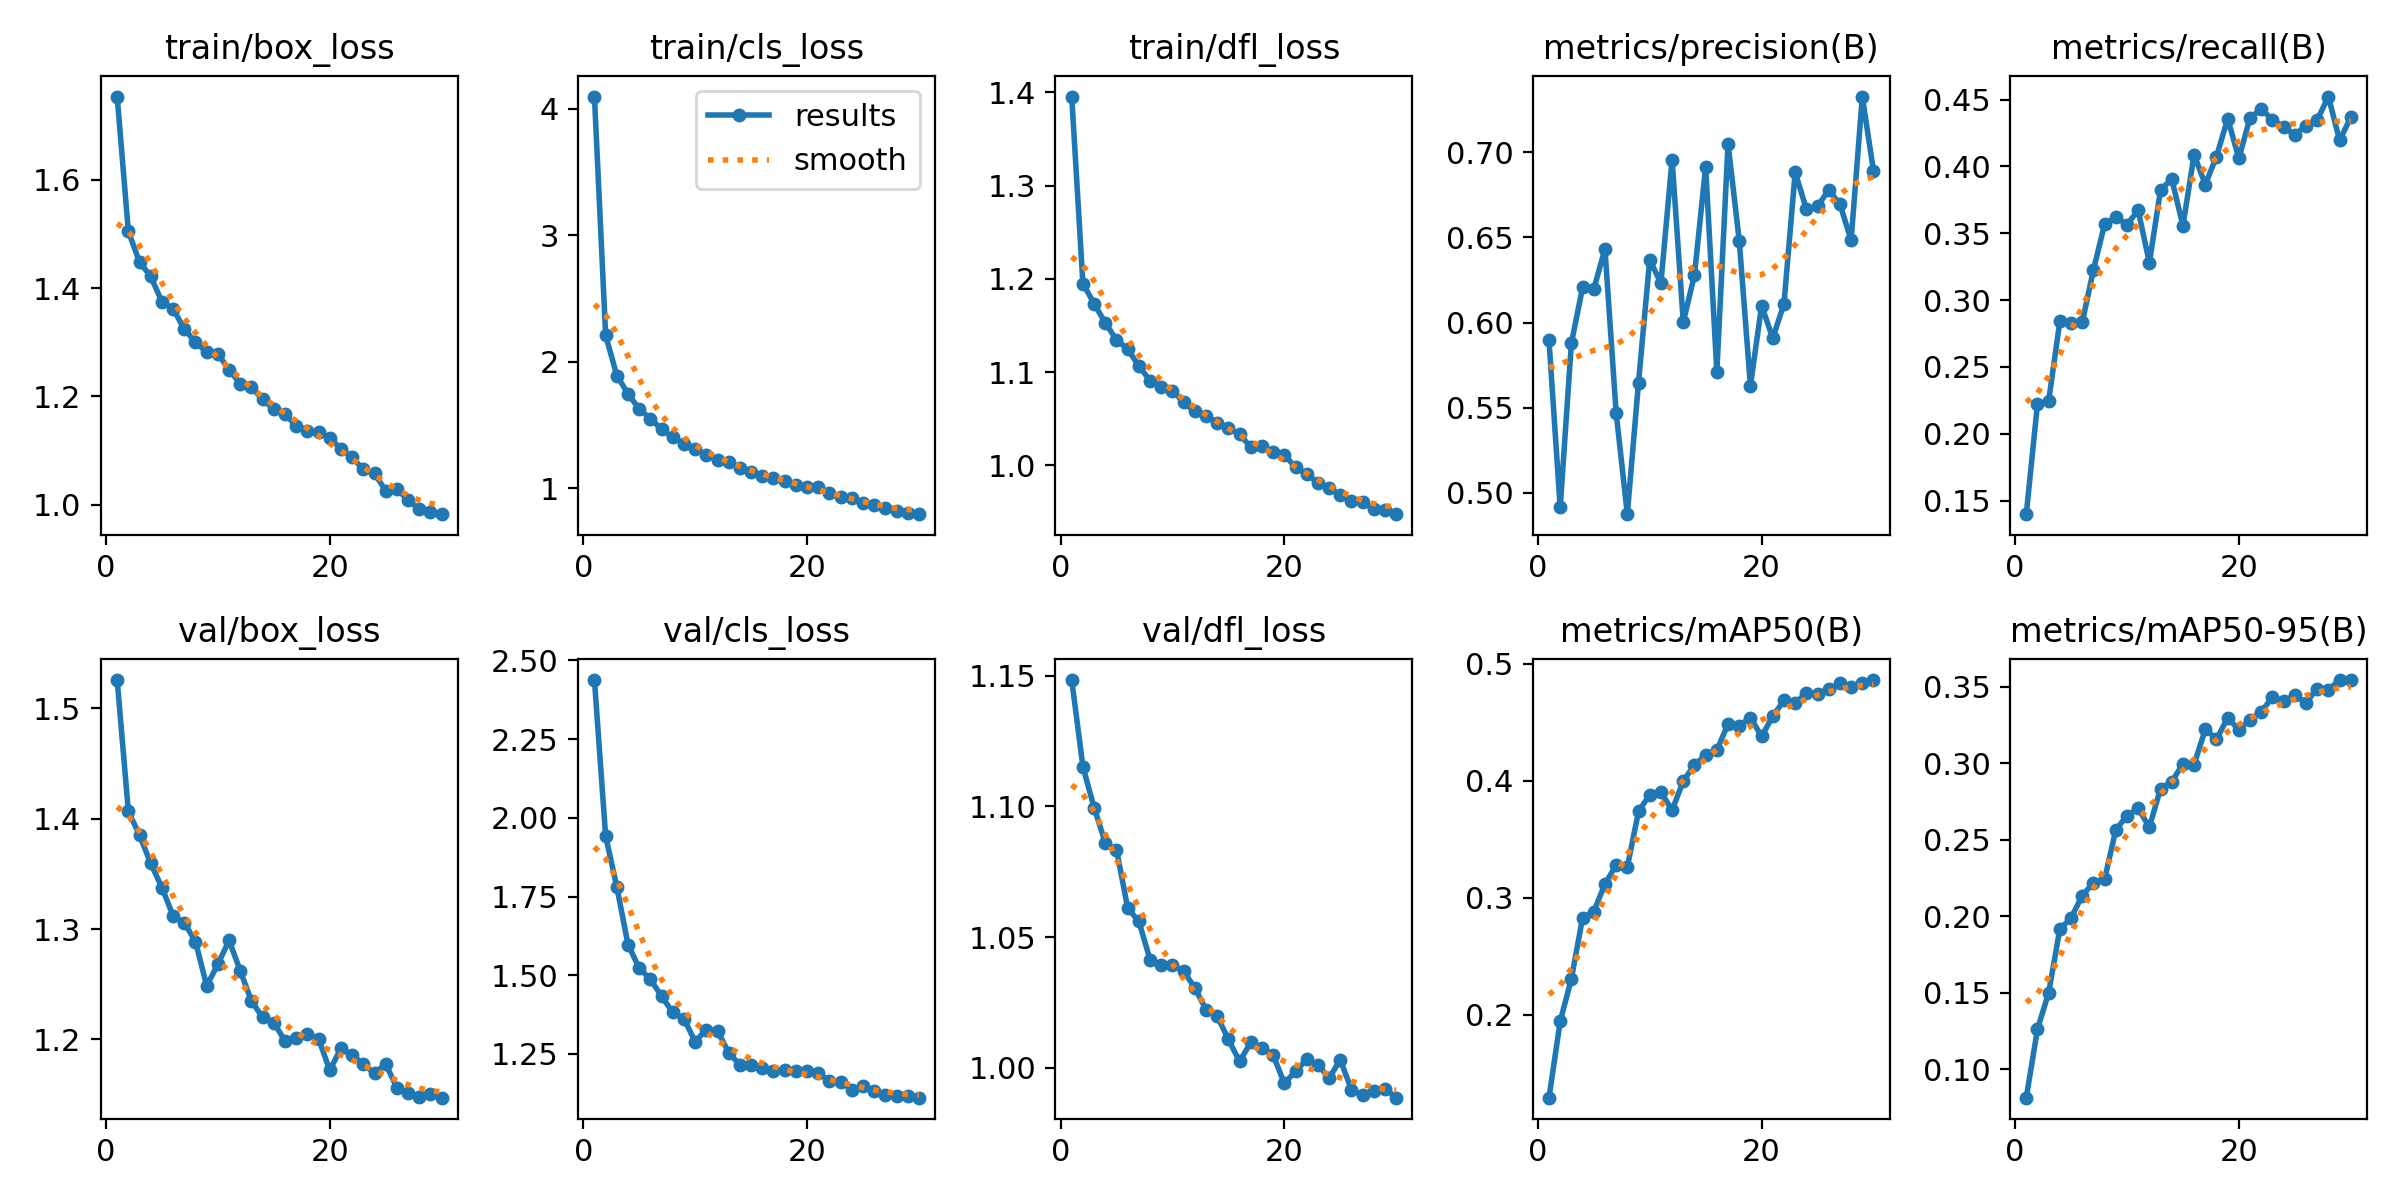

In [58]:
from PIL import Image
img = Image.open("/kaggle/working/runs/detect/fathomnet_run/final_train-2/results.png")
img

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/working/runs/detect/fathomnet_run/final_train-2/results.csv")
df.columns = df.columns.str.strip()  # bazen kolon isimlerinde boşluk oluyor
print(df.columns.tolist())

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


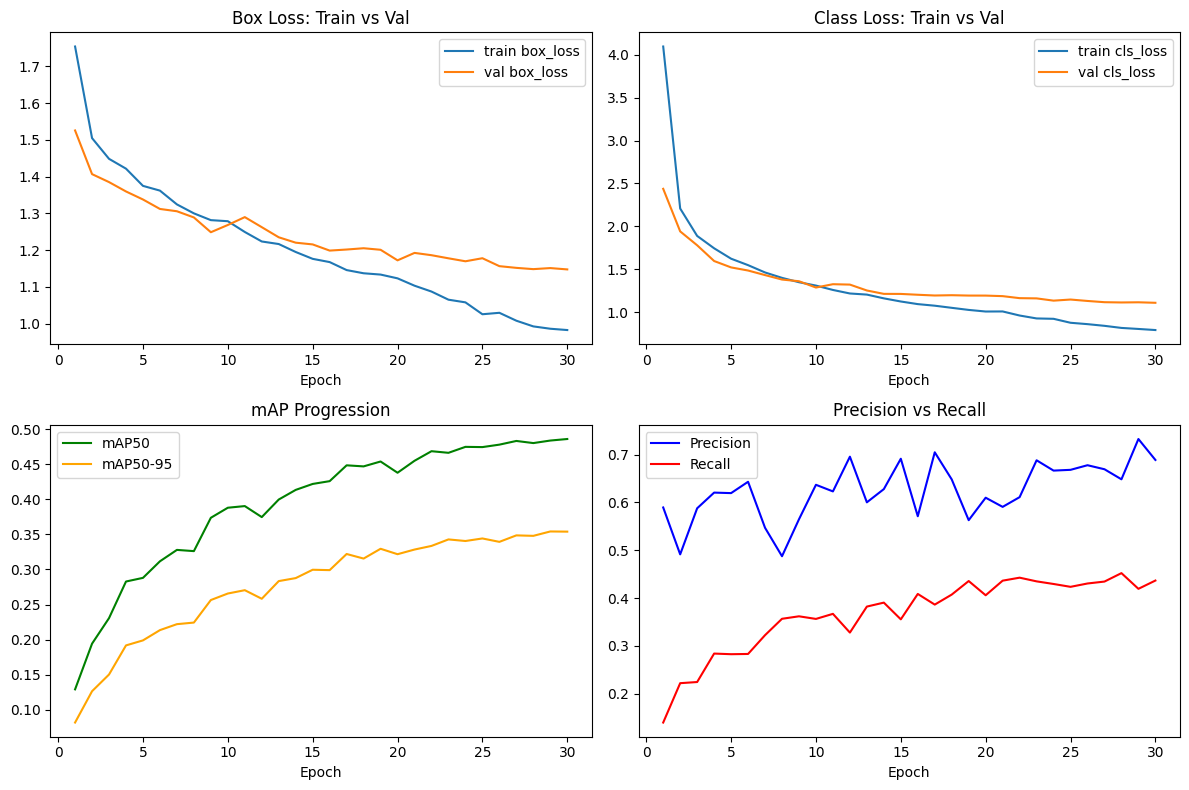

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loss 
axes[0,0].plot(df['epoch'], df['train/box_loss'], label='train box_loss')
axes[0,0].plot(df['epoch'], df['val/box_loss'], label='val box_loss')
axes[0,0].set_title('Box Loss: Train vs Val')
axes[0,0].set_xlabel('Epoch')
axes[0,0].legend()

axes[0,1].plot(df['epoch'], df['train/cls_loss'], label='train cls_loss')
axes[0,1].plot(df['epoch'], df['val/cls_loss'], label='val cls_loss')
axes[0,1].set_title('Class Loss: Train vs Val')
axes[0,1].set_xlabel('Epoch')
axes[0,1].legend()

# mAP 
axes[1,0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='green')
axes[1,0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='orange')
axes[1,0].set_title('mAP Progression')
axes[1,0].set_xlabel('Epoch')
axes[1,0].legend()

# Precision/Recall 
axes[1,1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='blue')
axes[1,1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='red')
axes[1,1].set_title('Precision vs Recall')
axes[1,1].set_xlabel('Epoch')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/training_analysis.png', dpi=150)
plt.show()

1. Box Loss: Train vs. Validation
The train box loss shows a consistent and smooth decrease throughout training.

The validation box loss plateaus after epoch 15, stabilizing around 1.1–1.2, while train loss continues to decrease.

This indicates a slight onset of overfitting, where the model begins fitting the training set slightly better than the validation set. While not critical, it is worth noting.

2. Class Loss: Train vs. Validation
Both train and validation class losses follow a closely aligned, steady downward trend.

There is no indication of overfitting in classification; the learning curve remains healthy.

3. mAP Progression
Most notably, mAP50 (0.49) and mAP50-95 (0.35) continue an upward trajectory with no sign of flattening out at epoch 30.

This strongly suggests that extending the number of training epochs could yield further performance improvements.

4. Precision vs. Recall
Precision remains relatively high with minor fluctuations (ranging between 0.55 and 0.75).

Recall increases steadily from 0.15 to 0.45.

Interpretation: When the model predicts a target, it is generally accurate (high precision); however, it still misses a significant number of objects (lower recall at 0.45). In the context of Positive-Unlabeled (PU) learning, this behavior is expected, as the model may overlook objects belonging to unannotated or under-represented classes.

In [61]:
from ultralytics import YOLO

best_model = YOLO("/kaggle/working/runs/detect/fathomnet_run/final_train-2/weights/best.pt")

In [65]:
from pathlib import Path

ROOT = Path("/kaggle/temp/fathomnet-2026")
yolo_dir = ROOT / "yolo"
print(yolo_dir.exists())

True


In [66]:
import glob

val_images_paths = glob.glob(str(yolo_dir / "images" / "val" / "*"))[:6]

results = best_model.predict(
    source=val_images_paths,
    imgsz=512,
    conf=0.25,
    save=True,
)


0: 512x512 1 soft coral, 8.4ms
1: 512x512 1 bony fish, 20 brittle stars, 1 feather star, 1 sea star, 1 sponge, 8.4ms
2: 512x512 4 sea fans, 3 sponges, 8.4ms
3: 512x512 3 anemones, 1 sea fan, 8.4ms
4: 512x512 3 brittle stars, 1 sponge, 7 urchins, 8.4ms
5: 512x512 2 bony fishs, 2 crabs, 8.4ms
Speed: 1.9ms preprocess, 8.4ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /kaggle/working/runs/detect/predict


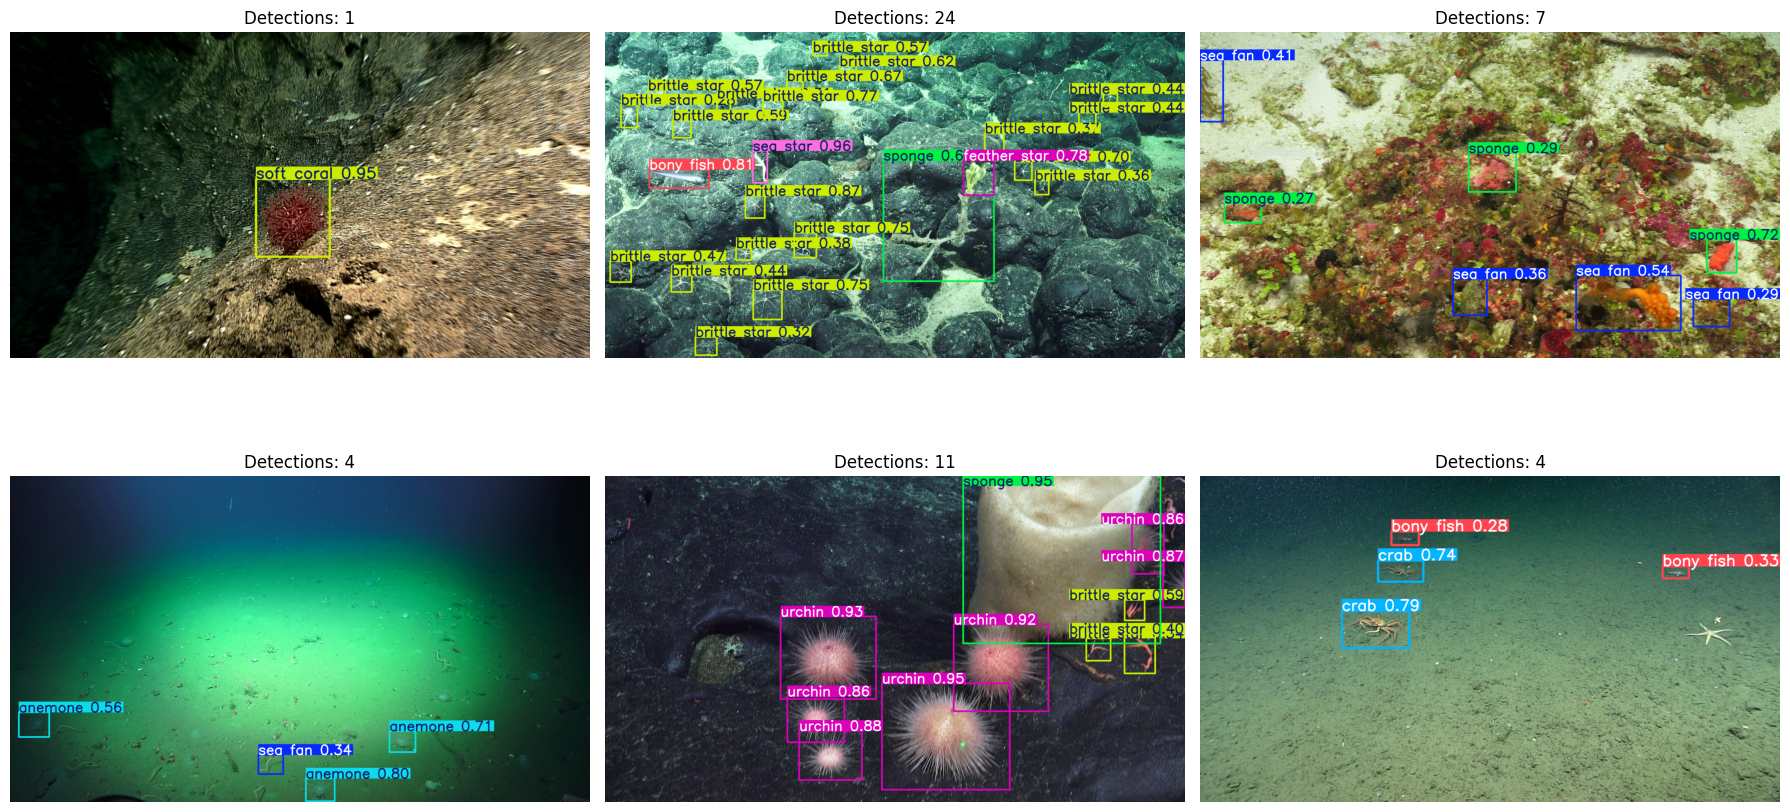

In [67]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, r in enumerate(results):
    im_array = r.plot()  
    axes[i].imshow(im_array[..., ::-1])  
    axes[i].axis('off')
    axes[i].set_title(f"Detections: {len(r.boxes)}")

plt.tight_layout()
plt.savefig('/kaggle/working/predictions_sample.png', dpi=150)
plt.show()

In [68]:
metrics = best_model.val(
    data=str(yolo_dir / "data.yaml"),
    imgsz=512,
    split="val",
)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 822.6±634.9 MB/s, size: 8707.9 KB)
val: Scanning /kaggle/temp/fathomnet-2026/yolo/labels/val.cache... 1288 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1288/1288 600.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 81/81 1.0it/s 1:210.2sss
                   all       1288       4674      0.732      0.419      0.484      0.353
              amphipod          7         11          1          0     0.0493     0.0158
               anemone        159        261      0.755       0.33      0.453      0.305
              barnacle          5          7      0.651      0.429      0.457      0.418
          benthic worm          8          9          1          0    0.00147   0.000855
               bivalve          4          5      0.234        0.2      0.231      0.206
           bla

In [69]:
import pandas as pd

class_results = pd.DataFrame({
    "class": class_names,
    "AP50": metrics.box.ap50,
    "AP50-95": metrics.box.ap,
})
class_results_sorted = class_results.sort_values("AP50", ascending=False)
print(class_results_sorted.to_string(index=False))

                    class     AP50  AP50-95
                 pyrosome 0.966429 0.883571
                  octopus 0.919776 0.721660
                larvacean 0.912500 0.709875
                   urchin 0.884446 0.591357
                   chiton 0.795000 0.461625
   physonect siphonophore 0.772561 0.543709
              stony coral 0.751869 0.597756
                bony fish 0.747167 0.521871
                     crab 0.734697 0.609620
                  hydroid 0.665000 0.565500
                  sea fan 0.641235 0.467472
             feather star 0.622866 0.379133
               soft coral 0.613862 0.458022
                   sponge 0.602297 0.485551
calycophoran siphonophore 0.521826 0.318847
             brittle star 0.517800 0.269312
            squat lobster 0.509438 0.363183
                   shrimp 0.473037 0.270071
                 barnacle 0.456579 0.418171
                  anemone 0.452684 0.305290
                 sea star 0.378970 0.260905
             sea cucumber 0.3747

Class-wise AP50 scores demonstrate a strong direct correlation between model performance and the number of instances present in the training set (e.g., urchin: 1,437 instances → AP50 0.88 vs. isopod: 2 instances → AP50 0.00).

This trend directly highlights the core challenge of the competition: the Positive-Unlabeled (PU) learning problem. Rare and under-represented species are significantly more likely to remain unannotated ('unlabeled') in the dataset. Consequently, the model treats these unlabelled instances as background noise/negatives, making it exceptionally difficult to learn robust visual patterns for minority classes

## Function-Based Implementation (Google Python Style Guide)

The training, tuning, prediction, and evaluation steps above were run as direct script-style calls. Below, the same logic is refactored into reusable, documented functions, following the [Google Python Style Guide](https://google.github.io/styleguide/pyguide.html) docstring format (`Args:` / `Returns:` sections). This makes the pipeline easier to re-run, test, and reuse for future experiments (e.g. the test set submission).


In [ ]:
from pathlib import Path
from typing import Any, Optional
import pandas as pd
from ultralytics import YOLO


def load_yolo_model(model_name: str = "yolov8s.pt") -> YOLO:
    """Loads a YOLO model with pretrained weights.

    Args:
        model_name: Name or path of the YOLO checkpoint to load. Defaults
            to the pretrained YOLOv8 small model.

    Returns:
        An initialized ultralytics YOLO model instance.
    """
    return YOLO(model_name)


def train_yolo_model(
    model: YOLO,
    data_yaml: str,
    epochs: int = 30,
    imgsz: int = 512,
    batch: int = 32,
    cache: bool = True,
    device: int = 0,
    project: str = "fathomnet_run",
    name: str = "final_train",
    lr0: Optional[float] = None,
) -> Any:
    """Fine-tunes a YOLO model on a custom dataset.

    Args:
        model: A YOLO model instance to fine-tune.
        data_yaml: Path to the dataset's data.yaml configuration file.
        epochs: Number of training epochs. Defaults to 30.
        imgsz: Input image size in pixels used during training. Defaults
            to 512.
        batch: Number of images per training batch. Defaults to 32.
        cache: Whether to cache images in RAM to speed up training.
            Defaults to True.
        device: GPU device index to train on. Defaults to 0.
        project: Parent directory name where training runs are saved.
        name: Name of this specific training run.
        lr0: Optional initial learning rate override. Note: when the
            model's optimizer is set to "auto" (the default), Ultralytics
            ignores this value and computes its own optimal learning
            rate instead.

    Returns:
        The Ultralytics training results object, containing metrics and
        paths to saved artifacts such as best.pt.
    """
    train_kwargs = dict(
        data=data_yaml,
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        cache=cache,
        device=device,
        project=project,
        name=name,
    )
    if lr0 is not None:
        train_kwargs["lr0"] = lr0
    return model.train(**train_kwargs)


def run_hyperparameter_search(
    data_yaml: str,
    configs: list[dict],
    epochs: int = 5,
    imgsz: int = 640,
    device: int = 0,
    project: str = "fathomnet_tuning",
) -> dict[str, Any]:
    """Runs a small grid search over learning rate and batch size.

    Args:
        data_yaml: Path to the dataset's data.yaml configuration file.
        configs: A list of dicts, each with keys "name", "lr0", and
            "batch", specifying one configuration to try.
        epochs: Number of epochs to train each configuration for.
            Defaults to 5, since these are short comparison runs.
        imgsz: Input image size in pixels used during training.
        device: GPU device index to train on.
        project: Parent directory name where tuning runs are saved.

    Returns:
        A dictionary mapping each configuration's name to its training
        results object.
    """
    results_by_config = {}
    for cfg in configs:
        model = load_yolo_model("yolov8s.pt")
        result = train_yolo_model(
            model=model,
            data_yaml=data_yaml,
            epochs=epochs,
            imgsz=imgsz,
            batch=cfg["batch"],
            lr0=cfg["lr0"],
            device=device,
            project=project,
            name=cfg["name"],
        )
        results_by_config[cfg["name"]] = result
    return results_by_config


def predict_on_images(
    model: YOLO,
    image_paths: list[str],
    imgsz: int = 512,
    conf: float = 0.25,
    save: bool = True,
) -> list[Any]:
    """Runs object detection inference on a list of images.

    Args:
        model: A trained YOLO model instance.
        image_paths: File paths of the images to run inference on.
        imgsz: Input image size in pixels used during inference.
        conf: Minimum confidence threshold for a detection to be kept.
        save: Whether to save annotated output images to disk.

    Returns:
        A list of Ultralytics Results objects, one per input image.
    """
    return model.predict(source=image_paths, imgsz=imgsz, conf=conf, save=save)


def evaluate_model(
    model: YOLO,
    data_yaml: str,
    imgsz: int = 512,
    split: str = "val",
) -> Any:
    """Evaluates a trained YOLO model on a dataset split.

    Args:
        model: A trained YOLO model instance.
        data_yaml: Path to the dataset's data.yaml configuration file.
        imgsz: Input image size in pixels used during evaluation.
        split: Which dataset split to evaluate on, e.g. "val" or "test".

    Returns:
        An Ultralytics metrics object exposing box-level precision,
        recall, and mAP statistics, both overall and per class.
    """
    return model.val(data=data_yaml, imgsz=imgsz, split=split)


def summarize_classwise_results(
    metrics: Any, class_names: list[str]
) -> pd.DataFrame:
    """Builds a per-class AP50 / AP50-95 summary table.

    Args:
        metrics: The metrics object returned by `evaluate_model`.
        class_names: Ordered list of class names matching the model's
            class indices.

    Returns:
        A pandas DataFrame with one row per class, sorted by AP50 in
        descending order.
    """
    class_results = pd.DataFrame({
        "class": class_names,
        "AP50": metrics.box.ap50,
        "AP50-95": metrics.box.ap,
    })
    return class_results.sort_values("AP50", ascending=False)


In [ ]:
# --- Example usage: reproducing the earlier steps with the functions above ---

# 1. Hyperparameter search (equivalent to the earlier manual loop)
tuning_configs = [
    {"name": "lr_default", "lr0": 0.01, "batch": 16},
    {"name": "lr_low", "lr0": 0.001, "batch": 16},
]
# tuning_results = run_hyperparameter_search(str(yaml_path), tuning_configs)

# 2. Final training run
model = load_yolo_model("yolov8s.pt")
# train_results = train_yolo_model(model, str(yaml_path), epochs=30, imgsz=512, batch=32)

# 3. Prediction on a batch of validation images
# preds = predict_on_images(model, val_images_paths, imgsz=512, conf=0.25)

# 4. Evaluation + class-wise summary
# metrics = evaluate_model(model, str(yolo_dir / "data.yaml"), imgsz=512, split="val")
# class_summary = summarize_classwise_results(metrics, class_names)
# class_summary.head(10)


**Note:** The calls above are commented out because the corresponding training/evaluation runs were already executed earlier in this notebook (see the cells producing the loss curves, predictions, and evaluation table). Uncomment them to re-run the full pipeline end-to-end using the function-based interface, e.g. for the test set submission.